In [1]:
# ## 07 · The cumulative walk — the whole model in one cell
#
# ## Executive summary (read this first)
#
# The team's ONE production model (forecast_models.py, since 2026-09-27) is the cumulative walk. This cell holds all
# of it as plain functions, in the order it runs. Run this cell, then call forecast_unit(unit_dir).
#
#   read_unit(unit_dir)             card.toml + the panel parquet files
#   fit_walk(unit, adjustments)     sd (plain or EWMA) -> scale; correlation -> Cholesky L; last value; horizon steps
#   draw_walk(fit, n_draws, seed)   the draws, shape (n_draws, n_assets, n_horizons)
#   forecast_unit(unit_dir)         all three, like a submission run (500 draws, seed 0, text off by default)
#   fit_table / summary_table       what the fit and the draws look like, as tables
#   to_forecast_table(draws, unit)  the forecast.parquet layout: one row per (draw, asset, horizon)
#
# The equation, for asset a at horizon k (leg j runs from horizon j-1 to horizon j, h_0 = 0):
#
#   value_a(h_k) = last_a + shift_a + sum_{j<=k}  t_j * (L e_j)_a * scale_a * sqrt(h_j - h_{j-1})
#
#   scale = sd * widen_family * widen_text     (the same rule on every card)
#   e_j   = independent normals, fresh each leg;  L = Cholesky factor of the assets' step correlation
#   t_j   = sqrt((nu - 2) / W), W ~ chi2(nu): one per leg, shared by all assets of a draw (fat tails)
#
# Only the data plumbing is reused from forecast_models (the as-of filter, the gap guard, log-return steps and the
# month count on monthly panels), so the numbers are production's. Section 5 checks the draws equal production's,
# exactly, on all 103 cards, with the text off and on.

import pathlib, sys, tomllib
import numpy as np, pandas as pd, pyarrow.parquet as pq

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "model_baseline" else pathlib.Path.cwd() / "model_baseline"
REPO, UNITS = HERE.parent, HERE.parent / "units"
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))
import forecast_models as fm      # data plumbing only: fm._series, fm._step_frame, fm._panel_steps

# ---------------------------------------------------------------- settings (the same as forecast_models; see section 5)
WALK_SETTINGS = {                 # window = steps for the sd and the correlation; nu = Student-t; halflife = EWMA sd
    "T2-F1": {"window": 42,  "widen": 1.2, "nu": 5, "halflife": None},
    "T2-F2": {"window": 130, "widen": 1.1, "nu": 4, "halflife": None},
    "T2-F3": {"window": 130, "widen": 1.2, "nu": 4, "halflife": None},
    "T2-F4": {"window": 260, "widen": 1.2, "nu": 5, "halflife": 63},
}
PLAIN = {"window": 260, "widen": 1.0, "nu": None, "halflife": None}   # a family not listed above
EWMA_HALFLIVES = 8                # EWMA sd uses the last 8 x halflife rows: F4 = 8 x 63 = 504 (older weights < 0.4%)
SKEW_SHAPE = 5.0                  # the text's skew in [-1, 1] becomes a skew-normal shape in [-5, 5]
N_DRAWS, SEED = 500, 0            # what a submission run uses
NEUTRAL = {"shift": 0.0, "widen": 1.0, "skew": 0.0}   # the text is off


def read_unit(unit_dir):
    """card.toml and every panel parquet in the unit folder."""
    unit_dir = pathlib.Path(unit_dir)
    card = tomllib.loads((unit_dir / "card.toml").read_text())
    t = card["targets"]
    return {"id": unit_dir.name, "family": card.get("metadata", {}).get("category"),
            "asof": card["provenance"]["data_cutoff"], "assets": [str(a) for a in t["asset_ids"]],
            "horizons": [int(h) for h in t["horizons"]], "target_type": t.get("target_type"),
            "value_unit": t.get("value_unit", ""),
            "panels": {p.stem: pq.read_table(p) for p in sorted(unit_dir.glob("*.parquet"))}}


def ewma_sd(past, halflife):
    """sd where a step's weight halves every `halflife` steps back. `past`: rows oldest -> newest."""
    age = np.arange(len(past))[::-1]              # newest row = age 0
    w = 0.5 ** (age / halflife)
    w = w / w.sum()                               # shares add up to 1
    mean = w @ past
    return np.sqrt(w @ (past - mean) ** 2)


def skew_tilt(z, u, skew):
    """The text's skew: a skew-normal per asset, rescaled to mean 0 and variance 1. skew = 0 gives z back."""
    alpha = skew * SKEW_SHAPE
    delta = alpha / np.sqrt(1.0 + alpha**2)
    mean_shift = delta * np.sqrt(2.0 / np.pi)
    var_scale = np.sqrt(np.clip(1.0 - delta**2 * (2.0 / np.pi), 1e-8, None))
    return (delta * u + np.sqrt(1.0 - delta**2) * z - mean_shift) / var_scale


def fit_walk(unit, adjustments=None):
    """Everything the draws need, per asset. `adjustments`: {asset: {"shift", "widen", "skew"}} from the text."""
    A, H, fam = unit["assets"], unit["horizons"], unit["family"]
    cfg = WALK_SETTINGS.get(fam, PLAIN)
    adj = adjustments or {a: dict(NEUTRAL) for a in A}
    per = lambda key, default: np.array([adj.get(a, {}).get(key, default) for a in A], dtype=float)
    returns = unit["target_type"] == "log_return"

    # history on or before the as-of, and its daily steps (today - yesterday; log returns on a log-return card)
    hist = {a: fm._series(unit["panels"], a, unit["asof"]) for a in A}
    window, hl = cfg["window"], cfg["halflife"]
    ewma_rows = int(EWMA_HALFLIVES * hl) if hl else 0
    steps = fm._step_frame(hist, A, returns, rows=max(window, ewma_rows))
    D = steps.iloc[-window:].to_numpy().T                        # (assets, window)

    # 1. sd of one step: plain over the window, or EWMA over the last 8 x halflife rows
    sd = D.std(axis=1) if hl is None else ewma_sd(steps.to_numpy()[-ewma_rows:], hl)

    # 2. widen = family x text
    widen = cfg["widen"] * per("widen", 1.0)

    # 3. correlation of the steps over the window -> Cholesky L (after a nudge to a valid correlation)
    corr = np.atleast_2d(np.corrcoef(D))
    corr = np.nan_to_num(corr, nan=0.0)
    np.fill_diagonal(corr, 1.0)
    w, v = np.linalg.eigh(corr)
    corr = v @ np.diag(np.clip(w, 1e-8, None)) @ v.T

    # 4. the start: last value (0 on a log-return card) + the text's shift. No drift.
    last = np.zeros(len(A)) if returns else np.array([hist[a].iloc[-1] for a in A], dtype=float)

    return {"unit": unit["id"], "family": fam, "assets": A, "horizons": H, "settings": cfg,
            "last": last, "centre": last + per("shift", 0.0),
            "sd": sd, "sd_method": "plain" if hl is None else f"EWMA hl={hl} over {ewma_rows} rows",
            "plain_sd": D.std(axis=1), "widen": widen, "scale": sd * widen,
            "corr": corr, "L": np.linalg.cholesky(corr), "skew": per("skew", 0.0), "nu": cfg["nu"],
            # 5. each horizon in panel steps: business days on a daily panel, months on a monthly one
            "hsteps": np.array([fm._panel_steps(hist[a], H, unit["asof"]) for a in A]),
            "history": hist}


def draw_walk(fit, n_draws=N_DRAWS, seed=SEED):
    """One accumulating path per draw. Returns (n_draws, n_assets, n_horizons)."""
    rng, rng_t = np.random.default_rng(seed), np.random.default_rng([seed, 7])   # t's W has its own stream
    k, H = len(fit["assets"]), fit["horizons"]
    out = np.empty((n_draws, k, len(H)))
    path, prev = np.zeros((n_draws, k)), np.zeros(k)
    for hi in np.argsort(H):                                  # leg by leg, in horizon order
        e = rng.standard_normal((n_draws, k))                 # independent normals
        z = e @ fit["L"].T                                    # correlated across assets (Cholesky)
        u = np.abs(rng.standard_normal((n_draws, k)))         # the skew's extra draw
        z = skew_tilt(z, u, fit["skew"])
        if fit["nu"] is not None:                             # Student-t: one W per draw, shared by all assets
            z = z * np.sqrt((fit["nu"] - 2.0) / rng_t.chisquare(fit["nu"], size=(n_draws, 1)))
        leg = fit["hsteps"][:, hi]                            # steps from 0 to this horizon
        path = path + z * fit["scale"] * np.sqrt(np.maximum(leg - prev, 0))   # add only the new steps
        prev = leg
        out[:, :, hi] = fit["centre"] + path
    return out


def forecast_unit(unit_dir, adjustments=None, n_draws=N_DRAWS, seed=SEED):
    """read -> fit -> draw. Returns (unit, fit, draws)."""
    unit = read_unit(unit_dir)
    fit = fit_walk(unit, adjustments)
    return unit, fit, draw_walk(fit, n_draws, seed)


def fit_table(fit):
    """One row per asset: the numbers the draws are built from."""
    rows = {}
    for i, a in enumerate(fit["assets"]):
        r = {"last": fit["last"][i], "sd": fit["sd"][i], "sd method": fit["sd_method"], "widen": fit["widen"][i],
             "scale": fit["scale"][i], "nu": fit["nu"]}
        for hi, h in enumerate(fit["horizons"]):
            r[f"steps @{h}"] = fit["hsteps"][i, hi]
            r[f"width @{h} = scale x sqrt(steps)"] = fit["scale"][i] * np.sqrt(fit["hsteps"][i, hi])
        rows[a] = r
    return pd.DataFrame(rows).T


def summary_table(draws, unit, q=(0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99)):
    """One row per (asset, horizon): quantiles, mean and sd of the draws."""
    rows = []
    for i, a in enumerate(unit["assets"]):
        for hi, h in enumerate(unit["horizons"]):
            x = draws[:, i, hi]
            rows.append({"asset": a, "horizon": h, **{f"{int(p * 100)}%": v for p, v in zip(q, np.quantile(x, q))},
                         "mean": x.mean(), "sd": x.std()})
    return pd.DataFrame(rows).set_index(["asset", "horizon"])


def to_forecast_table(draws, unit):
    """The forecast.parquet layout forecast_agent writes: draw, asset, horizon, value."""
    n, k, nh = draws.shape
    return pd.DataFrame({"draw": np.repeat(np.arange(n), k * nh),
                         "asset": np.tile(np.repeat(unit["assets"], nh), n),
                         "horizon": np.tile(unit["horizons"], n * k),
                         "value": draws.reshape(-1)})


pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print("model loaded:", ", ".join(f"{k} {v['window']}/{v['widen']}/nu={v['nu']}" + (f"/EWMA hl={v['halflife']}" if v["halflife"] else "")
                                for k, v in WALK_SETTINGS.items()))

model loaded: T2-F1 42/1.2/nu=5, T2-F2 130/1.1/nu=4, T2-F3 130/1.2/nu=4, T2-F4 260/1.2/nu=5/EWMA hl=63


## What the cells below show

The first cell above **is** the model. Everything below only runs it and shows what comes out.

- **§1 One asset, two horizons (F1):** `t2-F1-greater-confidence-2024`, UST_2Y at 126 and 189 business days.
- **§2 Two assets, two horizons (F3):** `t2-F3-inversion-persistence-2019`, UST_2Y and UST_10Y at 63 and 126.
  This is where the Cholesky factor `L` matters.
- **§3 One asset, one horizon (F4):** `t2-F4-svb-whiplash-2023`, where the EWMA sd acts.
- **§4 What the text changes:** `shift`, `widen`, `skew` on the same card.
- **§5 Check:** these functions give **exactly** production's draws (`forecast_models.build_draws`) on all 103
  cards, with the text off and on.

The output of the model is always one array, `draws`, shape **(n_draws, n_assets, n_horizons)** = (500, assets,
horizons). `to_forecast_table` turns it into the `forecast.parquet` the scorer reads: one row per
(draw, asset, horizon). The examples run with the text off (shift 0, widen 1, skew 0): the model's own forecast,
before the LLM adjusts it.

## 0 — Plot style

In [2]:
import matplotlib as mpl, matplotlib.pyplot as plt
INK, INK2, GRID, PATH, SEL = "#0b0b0b", "#52514e", "#e6e5e1", "#b9b8b3", "#7a2e8e"
ACOL = ["#2a78d6", "#eb6834"]
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2, "axes.titlelocation": "left",
                     "legend.frameon": False, "font.size": 10})


def fan(ax, unit, fit, draws, i, n_hist=130, n_paths=40):
    """History, 40 of the draws as paths, and the 5-95% / 25-75% of all draws at each horizon."""
    a, H = unit["assets"][i], unit["horizons"]
    hist = fit["history"][a].iloc[-n_hist:].to_numpy()
    ax.plot(np.arange(-len(hist) + 1, 1), hist, color=INK, lw=1.6, label="history")
    for d in range(n_paths):
        ax.plot([0, *H], [fit["centre"][i], *draws[d, i, :]], color=PATH, lw=.7, alpha=.7,
                label="40 draws" if d == 0 else None)
    for hi, h in enumerate(H):
        q = np.quantile(draws[:, i, hi], [.05, .25, .5, .75, .95])
        ax.vlines(h, q[0], q[4], color=ACOL[i], lw=6, alpha=.35, label="5-95%" if hi == 0 else None)
        ax.vlines(h, q[1], q[3], color=ACOL[i], lw=12, alpha=.85, label="25-75%" if hi == 0 else None)
        ax.hlines(q[2], h - 4, h + 4, color="white", lw=2)
    ax.plot([0, *H], [fit["centre"][i], *draws[0, i, :]], color=SEL, lw=2, marker="o", ms=4, label="draw #1")
    ax.axvline(0, color=INK2, lw=.8, ls=":")
    ax.set_xlabel("business days from the as-of"); ax.set_title(f"{a} ({unit['value_unit']})")

## 1 — One asset, two horizons (F1)

`t2-F1-greater-confidence-2024`: UST_2Y at 126 and 189 business days after 2024-01-31. F1 settings: window 42,
widen 1.2, Student-t ν = 5, plain sd. One asset, so `L = [[1]]` and Cholesky does nothing; two horizons, so each
draw is two legs (0 → 126, then 126 → 189).

In [3]:
unit, fit, draws = forecast_unit(UNITS / "t2-F1-greater-confidence-2024")
print("draws.shape =", draws.shape, "  = (n_draws, n_assets, n_horizons)")
print("assets:", unit["assets"], "  horizons:", unit["horizons"], "  as of:", unit["asof"])
print("\nthe fit:")
display(fit_table(fit))
print("L =", fit["L"].round(4).tolist(), "  (one asset)")

draws.shape = (500, 1, 2)   = (n_draws, n_assets, n_horizons)
assets: ['UST_2Y']   horizons: [126, 189]   as of: 2024-01-31

the fit:


,last,sd,sd method,widen,scale,nu,steps @126,width @126 = scale x sqrt(steps),steps @189,width @189 = scale x sqrt(steps)
UST_2Y,4.2700,0.0784,plain,1.2000,0.0941,5,126.0000,1.0558,189.0000,1.2931


L = [[1.0]]   (one asset)


The first five draws, as the array (`draws[d, asset, horizon]`) and as the `forecast.parquet` rows:

In [4]:
display(pd.DataFrame(draws[:5, 0, :], columns=[f"UST_2Y @{h}" for h in unit["horizons"]]).rename_axis("draw"))
ft = to_forecast_table(draws, unit)
print(f"forecast table: {len(ft):,} rows = {draws.shape[0]} draws x {draws.shape[1]} asset x {draws.shape[2]} horizons")
display(ft.head(6))

,UST_2Y @126,UST_2Y @189
draw,,
0,4.4081,5.0982
1,4.1703,4.3088
2,4.7379,4.8474
3,4.3391,4.5122
4,3.7426,3.0377


forecast table: 1,000 rows = 500 draws x 1 asset x 2 horizons


,draw,asset,horizon,value
0,0,UST_2Y,126,4.4081
1,0,UST_2Y,189,5.0982
2,1,UST_2Y,126,4.1703
3,1,UST_2Y,189,4.3088
4,2,UST_2Y,126,4.7379
5,2,UST_2Y,189,4.8474


Summarised over all 500 draws. `sd` should be close to `scale × √steps` from the fit table (it is a sample of 500).

1%     5%    25%    50%    75%    95%    99%   mean     sd
asset  horizon                                                               
UST_2Y 126     0.9696 2.5205 3.6499 4.2322 4.8529 5.7919 6.6533 4.2088 1.0525
       189     0.5955 1.8514 3.4857 4.2255 5.0567 6.1695 7.0945 4.2188 1.3458

corr(UST_2Y @126, UST_2Y @189) = 0.807   model: sqrt(126 / 189) = 0.816   (day 189 is reached through day 126)


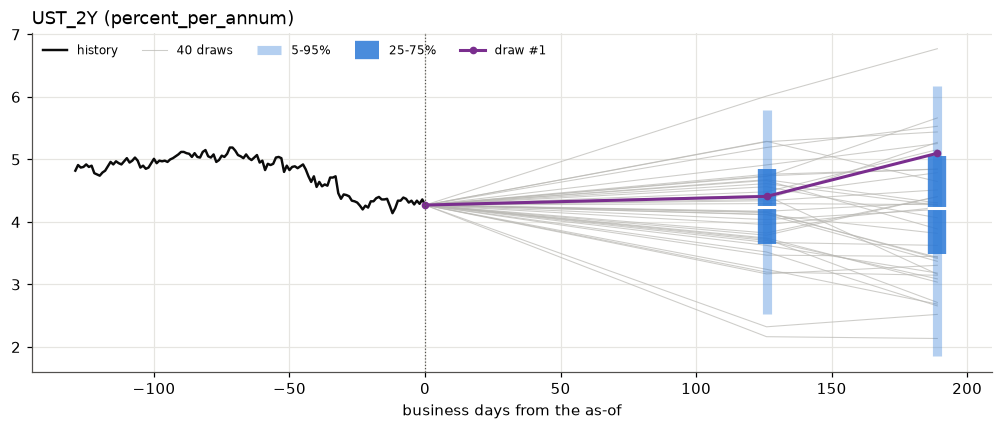

In [5]:
display(summary_table(draws, unit))
print(f"corr(UST_2Y @126, UST_2Y @189) = {np.corrcoef(draws[:, 0, 0], draws[:, 0, 1])[0, 1]:.3f}"
      f"   model: sqrt(126 / 189) = {np.sqrt(126 / 189):.3f}   (day 189 is reached through day 126)")
fig, ax = plt.subplots(figsize=(9, 3.8), layout="constrained")
fan(ax, unit, fit, draws, 0); ax.legend(loc="upper left", ncols=5, fontsize=8); plt.show()

## 2 — Two assets, two horizons (F3)

`t2-F3-inversion-persistence-2019`: UST_2Y and UST_10Y at 63 and 126 business days after 2019-08-14. F3 settings:
window 130, widen 1.2, ν = 4. Two assets, so Cholesky turns two independent normals into two correlated ones:

```
z_2Y  = e1
z_10Y = rho * e1 + sqrt(1 - rho^2) * e2        L = [[1, 0], [rho, sqrt(1 - rho^2)]]
```

In [6]:
unit2, fit2, draws2 = forecast_unit(UNITS / "t2-F3-inversion-persistence-2019")
print("draws.shape =", draws2.shape, "  = (n_draws, n_assets, n_horizons)")
display(fit_table(fit2))
rho = fit2["corr"][0, 1]
print(f"step correlation over the last 130 steps: rho = {rho:.4f}")
print("L =", fit2["L"].round(4).tolist(), f"  -> sqrt(1 - rho^2) = {np.sqrt(1 - rho**2):.4f}")
display(pd.DataFrame(draws2[:5].reshape(5, -1),
                     columns=[f"{a} @{h}" for a in unit2["assets"] for h in unit2["horizons"]]).rename_axis("draw"))
display(summary_table(draws2, unit2))

draws.shape = (500, 2, 2)   = (n_draws, n_assets, n_horizons)


,last,sd,sd method,widen,scale,nu,steps @63,width @63 = scale x sqrt(steps),steps @126,width @126 = scale x sqrt(steps)
UST_2Y,1.5800,0.0440,plain,1.2000,0.0528,4,63.0000,0.4193,126.0000,0.5930
UST_10Y,1.5900,0.0382,plain,1.2000,0.0459,4,63.0000,0.3643,126.0000,0.5152


step correlation over the last 130 steps: rho = 0.8404
L = [[1.0, 0.0], [0.8404, 0.5419]]   -> sqrt(1 - rho^2) = 0.5419


,UST_2Y @63,UST_2Y @126,UST_10Y @63,UST_10Y @126
draw,,,,
0,1.6328,1.7290,1.6024,1.6184
1,1.7551,1.5022,1.7314,1.3245
2,1.4388,0.8628,1.5318,1.0916
3,1.8861,1.4714,1.9181,1.6135
4,1.3195,0.8912,1.1793,0.7589


1%     5%    25%    50%    75%    95%    99%   mean     sd
asset   horizon                                                               
UST_2Y  63      0.2776 0.9420 1.3566 1.5454 1.7711 2.2118 2.5838 1.5492 0.4048
        126     0.0016 0.7304 1.2206 1.5464 1.8454 2.4320 3.0374 1.5405 0.5447
UST_10Y 63      0.4031 1.0448 1.3860 1.5670 1.7563 2.1277 2.4055 1.5661 0.3484
        126     0.2175 0.7975 1.2739 1.5627 1.8276 2.3337 2.7950 1.5531 0.4825

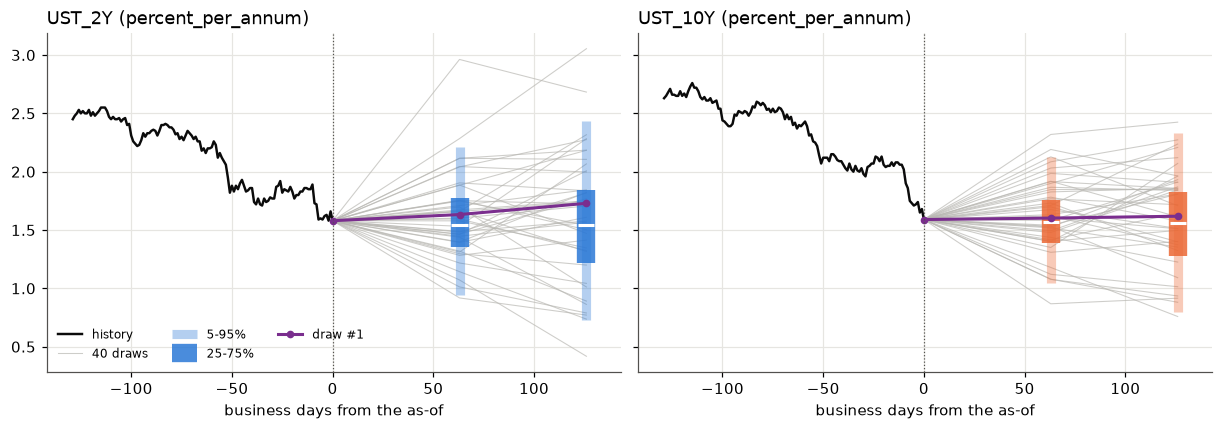

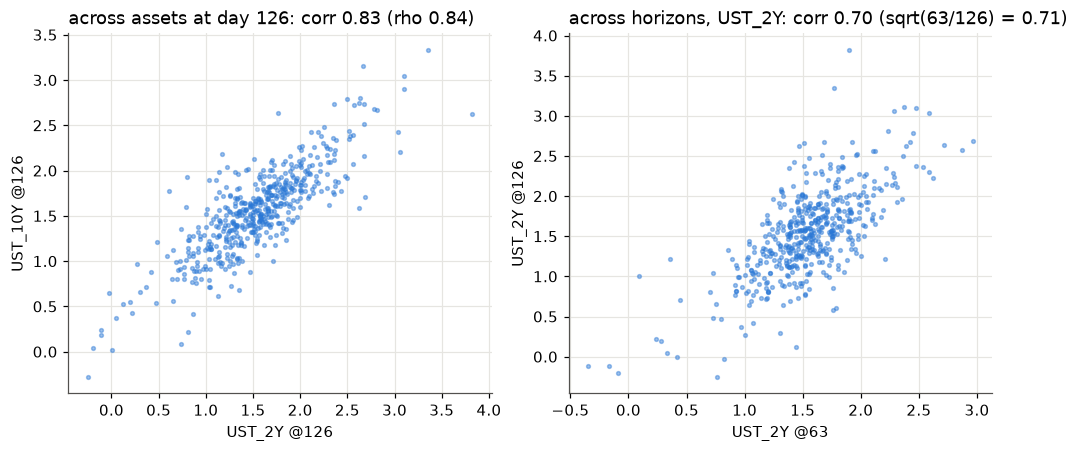

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained", sharey=True)
for i in range(2): fan(axes[i], unit2, fit2, draws2, i)
axes[0].legend(loc="lower left", ncols=3, fontsize=8); plt.show()

(h1, h2) = unit2["horizons"]
fig, axes = plt.subplots(1, 2, figsize=(9, 4), layout="constrained")
axes[0].scatter(draws2[:, 0, 1], draws2[:, 1, 1], s=6, alpha=.45, color=ACOL[0])
axes[0].set_title(f"across assets at day {h2}: corr {np.corrcoef(draws2[:, 0, 1], draws2[:, 1, 1])[0, 1]:.2f} (rho {rho:.2f})")
axes[0].set_xlabel(f"UST_2Y @{h2}"); axes[0].set_ylabel(f"UST_10Y @{h2}")
axes[1].scatter(draws2[:, 0, 0], draws2[:, 0, 1], s=6, alpha=.45, color=ACOL[0])
axes[1].set_title(f"across horizons, UST_2Y: corr {np.corrcoef(draws2[:, 0, 0], draws2[:, 0, 1])[0, 1]:.2f} (sqrt({h1}/{h2}) = {np.sqrt(h1 / h2):.2f})")
axes[1].set_xlabel(f"UST_2Y @{h1}"); axes[1].set_ylabel(f"UST_2Y @{h2}")
plt.show()

## 3 — One asset, one horizon (F4): EWMA sd

`t2-F4-svb-whiplash-2023`: UST_2Y at 21 business days after 2023-03-08. F4 is the only family with a halflife:
the sd is an EWMA over the last `EWMA_HALFLIVES × 63 = 504` rows, where a step's weight halves every 63 steps. The
window (260) still sets the correlation, which does nothing here (one asset). widen = 1.2 × the text's widen
(1.0 with the text off). One horizon means one leg: `value = last + t × e × scale × √21`.

In [8]:
unit4, fit4, draws4 = forecast_unit(UNITS / "t2-F4-svb-whiplash-2023")
display(fit_table(fit4))
print(f"EWMA sd {fit4['sd'][0]:.5f}  vs  plain sd of the last 260 steps {fit4['plain_sd'][0]:.5f}"
      f"  -> {fit4['sd'][0] / fit4['plain_sd'][0]:.2f}x")
print(f"widen = 1.2 (F4) x 1.0 (text off) = {fit4['widen'][0]}")
display(summary_table(draws4, unit4))

,last,sd,sd method,widen,scale,nu,steps @21,width @21 = scale x sqrt(steps)
UST_2Y,5.0500,0.0752,EWMA hl=63 over 504 rows,1.2000,0.0902,5,21.0000,0.4136


EWMA sd 0.07521  vs  plain sd of the last 260 steps 0.08064  -> 0.93x
widen = 1.2 (F4) x 1.0 (text off) = 1.2


,,1%,5%,25%,50%,75%,95%,99%,mean,sd
asset,horizon,,,,,,,,,
UST_2Y,21,3.7572,4.3647,4.8071,5.0352,5.2783,5.6462,5.9836,5.0260,0.4123


## 4 — What the text changes

The LLM half sends `shift`, `widen` and `skew` per asset. On the same F4 card:

- `shift` moves every draw by the same amount;
- `widen` multiplies the family's widen;
- `skew` stretches one tail while mean and variance stay the same.

In [9]:
cases = {"text off": None,
         "shift +0.10": {"UST_2Y": {"shift": 0.10, "widen": 1.0, "skew": 0.0}},
         "widen 1.1": {"UST_2Y": {"shift": 0.0, "widen": 1.1, "skew": 0.0}},
         "widen 2.0": {"UST_2Y": {"shift": 0.0, "widen": 2.0, "skew": 0.0}},
         "skew -0.6": {"UST_2Y": {"shift": 0.0, "widen": 1.0, "skew": -0.6}}}
rows = {}
for name, adj in cases.items():
    _, f_, d_ = forecast_unit(UNITS / "t2-F4-svb-whiplash-2023", adj)
    x = d_[:, 0, 0]
    rows[name] = {"total widen": f_["widen"][0], "scale": f_["scale"][0], "mean": x.mean(), "sd": x.std(),
                  "1%": np.quantile(x, .01), "median": np.median(x), "99%": np.quantile(x, .99)}
display(pd.DataFrame(rows).T)
print("total widen = 1.2 (F4) x the text's widen, whatever the text said.")

,total widen,scale,mean,sd,1%,median,99%
text off,1.2000,0.0902,5.0260,0.4123,3.7572,5.0352,5.9836
shift +0.10,1.2000,0.0902,5.1260,0.4123,3.8572,5.1352,6.0836
widen 1.1,1.3200,0.0993,5.0236,0.4535,3.6279,5.0337,6.0769
widen 2.0,2.4000,0.1805,5.0020,0.8246,2.4644,5.0204,6.9171
skew -0.6,1.2000,0.0902,5.0653,0.3898,3.9607,5.1022,5.8510


total widen = 1.2 (F4) x the text's widen, whatever the text said.


## 5 — Check: these functions are production

Every visible card, 500 draws, seed 0, compared with `forecast_models.build_draws` (what `forecast_agent` calls), with
the text off and with a made-up text answer on every asset (shift +0.05, widen 1.3, skew 0.4). Pass = the draws are
**identical** (max |difference| = 0), and the settings above equal production's.

In [10]:
assert WALK_SETTINGS == fm.WALK_SETTINGS, "settings differ from production"
assert SKEW_SHAPE == fm._SKEW_SHAPE_SCALE
rows = []
for ud in sorted(UNITS.glob("t2-F*")):
    u = read_unit(ud)
    for label, adj in (("text off", None),
                       ("text on", {a: {"shift": 0.05, "widen": 1.3, "skew": 0.4} for a in u["assets"]})):
        mine = draw_walk(fit_walk(u, adj))
        prod = fm.build_draws(u["panels"], u["assets"], u["horizons"], u["asof"],
                              adj or {a: dict(NEUTRAL) for a in u["assets"]}, N_DRAWS, SEED,
                              target_type=u["target_type"], family=u["family"])
        rows.append({"unit": u["id"], "family": u["family"], "text": label, "shape": "x".join(map(str, mine.shape)),
                     "max |diff|": float(np.abs(mine - prod).max())})
chk = pd.DataFrame(rows)
print(f"{chk.unit.nunique()} cards x 2 text settings: max |difference| over everything = {chk['max |diff|'].max():.1e}")
display(chk.groupby(["family", "text"])["max |diff|"].agg(["count", "max"]))

103 cards x 2 text settings: max |difference| over everything = 0.0e+00


count    max
family text                  
T2-F1  text off     23 0.0000
       text on      23 0.0000
T2-F2  text off     27 0.0000
       text on      27 0.0000
T2-F3  text off     22 0.0000
       text on      22 0.0000
T2-F4  text off     31 0.0000
       text on      31 0.0000

## 6 — Where this leaves things

- The first cell is the whole production model: about 100 lines, one function per step.
- Its output is one array, `draws` of shape (500, assets, horizons); `to_forecast_table` is the file the scorer reads.
- The family only changes four numbers (window, widen, ν, halflife). EWMA's row count is `EWMA_HALFLIVES × halflife`
  (504 on F4), named here and fixed in production (`8 * hl` in `forecast_models._fit_walk`).
- §5: identical to `forecast_models.build_draws` on all 103 cards, text off and on.